<a href="https://colab.research.google.com/github/feliperib286/5-semestre-fatec/blob/main/Exerc%C3%ADcio%20SVM%20e%20%C3%81rvores%20de%20Decis%C3%A3o%20atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados originais carregados:
  DIA       TEMPO TEMPERATURA UMIDADE  VENTO JOGA
0  D1  Ensolarado      Quente    Alta  Fraco  Não
1  D2  Ensolarado      Quente    Alta  Forte  Não
2  D3     Nublado      Quente    Alta  Fraco  Sim
3  D4     Chuvoso       Média    Alta  Fraco  Sim
4  D5     Chuvoso        Fria  Normal  Fraco  Sim 

Acurácia do modelo no dataset Play: 0.6667


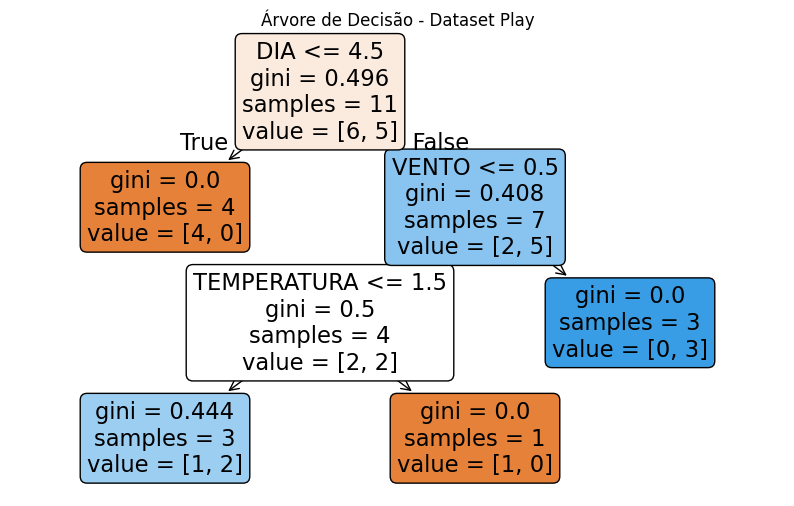

--- Avaliação Detalhada ---
Matriz de Confusão:
[[1 1]
 [0 1]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [13]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

# 1. Carregar os dados da planilha
# Ajuste o nome do arquivo se necessário (ex: 'play.csv' e mude para pd.read_csv)
nome_arquivo = 'Play 1.xlsx'
df_play = pd.read_excel(nome_arquivo)

print("Dados originais carregados:")
print(df_play.head(), "\n")

# 2. Pré-processamento: Converter dados categóricos (texto) para numéricos
# A árvore do scikit-learn requer que as classes sejam numéricas
df_codificado = df_play.copy()
for coluna in df_play.columns:
    df_codificado[coluna] = df_play[coluna].astype('category').cat.codes

# 3. Separar atributos preditivos (X) e atributo alvo (y)
# Presumimos que a última coluna seja o alvo (como 'JOGA')
nome_alvo = df_codificado.columns[-1]
X_play = df_codificado.drop(columns=[nome_alvo])
y_play = df_codificado[nome_alvo]

# 4. Dividir em treinamento e teste (ex: 80% treino, 20% teste)
X_ptreino, X_pteste, y_ptreino, y_pteste = train_test_split(X_play, y_play, test_size=0.2, random_state=42, stratify=y_play)

# 5. Treinar o modelo
arvore_play = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
arvore_play.fit(X_ptreino, y_ptreino)

# 6. Avaliar o desempenho
pred_play = arvore_play.predict(X_pteste)
acuracia_play = accuracy_score(y_pteste, pred_play)
print(f"Acurácia do modelo no dataset Play: {acuracia_play:.4f}")

# 7. (Opcional) Visualizar graficamente a árvore gerada
plt.figure(figsize=(10, 6))
tree.plot_tree(arvore_play, feature_names=X_play.columns, filled=True, rounded=True)
plt.title("Árvore de Decisão - Dataset Play")
plt.show()

from sklearn.metrics import classification_report, confusion_matrix

print("--- Avaliação Detalhada ---")
print("Matriz de Confusão:")
print(confusion_matrix(y_pteste, pred_play, labels=[0, 1]))

print("\nRelatório de Classificação:")
print(classification_report(y_pteste, pred_play, labels=[0, 1]))